In [1]:
#Amo evaluation
#FM 28.11.2025
import sys
sys.path.append('amos') 
# Import all ML orchestration functions
from amos.ml_orchestration import (
    ml_exp_with_timing,  # Main experiment function with timing preservation
    extract_timing_structure,
    save_midi_with_exact_timing_structure,
    KerasClassifierWrapper,
    build_lstm_classifier,
    build_transformer_classifier,
    clf_predict,
    defineXy,           # Data preparation function
    split_and_encode    # Train/test split with encoding
)
# Import MIDI processing functions  
from amos.midi2df2midi import midi_to_dataframe, save_midi_from_df
from amos.mappings import fill_quaterna_columns, learn_quaterna_mapping
# Import amo funtion
from amos.ml_orchestration import amo_with_doublings_multiclass

import pandas as pd
import numpy as np
from collections import defaultdict


from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

import matplotlib.pyplot as plt



/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
2025-12-09 12:20:37.568494: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765279237.586612   65919 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been

In [2]:
# amo_with_doublings
# Args:
  #      filein (str): Path to the source MIDI file to learn orchestration style from.
  #      fileout (str): Path to the target MIDI file to be orchestrated.
  #      ytarget (str, optional): The target variable for the model ('track-channel' or 'program').
  #                               Defaults to "track-channel".
  #      model (str, optional): The name of the machine learning model to use for orchestration.
  #     ("XGBoost","RandomForest", "DecisionTree", "NearestNeighbors", "MLP3", "NaiveBayes", "MLP1", "AdaBoost", "LSTMClassifier", "TransformerClassifier")
  #                             Defaults to "XGBoost".

In [3]:
def transpose(note, inverse=False, n_semitones=12):
    # Example: transpose pitch
    if inverse:
        n_semitones = - n_semitones
    new_note = note.copy()
    new_note['pitch'] = note['pitch'] + n_semitones
    return [ new_note ]

In [4]:
transformations = [
    (transpose, {'n_semitones': 12}),
    (transpose, {'n_semitones': 24}),
    (transpose, {'n_semitones': 46}),
    (transpose, {'n_semitones': -12}),
    (transpose, {'n_semitones': -24}),
    (transpose, {'n_semitones': -46}),
    #(split_duration, {'smallest_unit': 0.25}),
]

In [5]:
"""
Prompt by GV
create a python function to read the path of .mid files which contain the string "orch". Files are inside folders like "folder_name1/la_mer_1_orch.mid", "folder_name2/symphony_9_2_orch.mid", etc.
"""
import os

def find_orch_mid_files(root_dir='.'):
    result = []
    for dirpath, _, filenames in os.walk(root_dir):
        for name in filenames:
            if name.lower().endswith('.mid') and 'orch' in name.lower():
                result.append(os.path.join(dirpath, name))
    return result

In [6]:
root_dir='LOP_database_06_09_17/hand_picked_Spotify'
filenames = find_orch_mid_files(root_dir)
len(filenames)

55

In [ ]:
model_names = [
        "XGBoost",
        "XGBoost5",
        "XGBoost10",
        "XGBoost20",
        "XGBoost50",
        "RandomForest",
        "DecisionTree",
        #"LSTMClassifier",      # Added
        "NearestNeighbors",
        #"MLP3",   
        #"TransformerClassifier", # Added
        "NaiveBayes",
        #"MLP1",
        "AdaBoost",
        "Dummy0",
        "Dummy1",
        "DummyUnif",      
    ]

model_names_short = [
    'XGB',
    'XGB5',
    'XGB10',
    'XGB20',
    'XGB50',
    'RF',
    'DT',
    #'LSTM*',
    'NN',
    #'MLP3*',
    #'TF',
    'NB',
    #'MLP1',
    'AB',
    'D0',
    'D1',
    'DU',
    ]

classifiers = [
    XGBClassifier(),
    XGBClassifier(n_estimators = 5),
    XGBClassifier(n_estimators = 10),
    XGBClassifier(n_estimators = 20),
    XGBClassifier(n_estimators = 50),
    RandomForestClassifier(),
    DecisionTreeClassifier(),
    #KerasClassifierWrapper(build_lstm_classifier),      # Added LSTM
    KNeighborsClassifier(1),
    #MLPClassifier(hidden_layer_sizes=(128,128,128)),
    #KerasClassifierWrapper(build_transformer_classifier),# Added Transformer
    GaussianNB(),
    #MLPClassifier(),
    AdaBoostClassifier(),
    DummyClassifier(strategy='constant', constant=0),
    DummyClassifier(strategy='constant', constant=1),
    DummyClassifier(strategy='uniform'),
]

In [8]:
# Reduce for testing purposes, remove this cell for the actual experiment
N_files = 3 #len(filenames)
N_models = len(classifiers)

filenames = filenames[5:5+N_files]

model_names = model_names[:N_models]
classifiers = classifiers[:N_models]
model_names_short = model_names_short[:N_models]

In [9]:
# Initialize metrics collectors
s = (len(filenames),len(model_names))
ml_metrics = dict()
base_metrics_names = ["time",
                      "accuracy (train)",
                      "accuracy (test)",
                      "precision (train)",
                      "precision (test)",
                      "recall (train)",
                      "recall (test)",
                      "f1 (train)",
                      "f1 (test)",
                      ] #, "n_events", "n_classes"]
ml_metrics_names = base_metrics_names.copy()

for func, kwargs in transformations:
    trans_target_name = f"{func.__name__}_{kwargs}"
    for bmn in base_metrics_names:
        ml_metrics_names.append(f"{bmn} ({trans_target_name})")

for mn in ml_metrics_names:
    ml_metrics[mn] = np.zeros(s)

In [10]:
# Multiclass, with transformations
error_collection = []
for i, filein in enumerate(filenames):    
    for u, (model_name, clf) in enumerate(zip(model_names, classifiers)):
        try: 
            metrics = amo_with_doublings_multiclass(filein,fileout=None,model=model_name, tol=0.2, transformations=transformations)
            print(metrics)
            for mn in ml_metrics_names:
                # ml_metrics["accuracy"][i,u] = metrics["accuracy"]
                ml_metrics[mn][i,u] = metrics[mn]
        except Exception as e:
            print("Error")
            error_collection.append(f"Error with {filein} and model {model_name}: {e}")

print("\n????????? ERRORS ??????????")
for error in error_collection:
    print(error)

Learning orchestration style from: LOP_database_06_09_17/hand_picked_Spotify/2/symphony_9_2_orch.mid

========= PREPROCESSING =========
Mapping: [[3 'Corno inglese' 2 0]
 [5 'Clarinetti B' 4 0]
 [6 'Fagotti' 5 0]
 [15 'Violini I.' 11 0]
 [16 'Violini II.' 12 0]
 [17 'Viole' 13 0]
 [18 'Violoncelli' 14 0]
 [19 'Contrabassi' 15 0]]

Building reduced dataset with transformations
{'transformed': 36, 'direct': 1, 'none': 175}
Original size: (212, 15)
Dropping [161, 186, 190, 191, 193, 195, 196, 140, 171, 197, 198, 172, 143, 146, 173, 149, 152, 178, 97, 180, 207, 98, 99, 181, 208, 100, 209, 101, 102, 103, 104, 105, 106, 158, 107, 185, 111]
Size after drop: (175, 15)

Creating multi-hot encoding for notes with instrumental doubling
Number of classes: 8
Classes: [np.str_('15_11'), np.str_('16_12'), np.str_('17_13'), np.str_('18_14'), np.str_('19_15'), np.str_('3_2'), np.str_('5_4'), np.str_('6_5')]
Number of events in LOP_database_06_09_17/hand_picked_Spotify/2/symphony_9_2_orch.mid : 200
Last

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


{'transformed': 36, 'direct': 1, 'none': 175}
Original size: (212, 15)
Dropping [161, 186, 190, 191, 193, 195, 196, 140, 171, 197, 198, 172, 143, 146, 173, 149, 152, 178, 97, 180, 207, 98, 99, 181, 208, 100, 209, 101, 102, 103, 104, 105, 106, 158, 107, 185, 111]
Size after drop: (175, 15)

Creating multi-hot encoding for notes with instrumental doubling
Number of classes: 8
Classes: [np.str_('15_11'), np.str_('16_12'), np.str_('17_13'), np.str_('18_14'), np.str_('19_15'), np.str_('3_2'), np.str_('5_4'), np.str_('6_5')]
Number of events in LOP_database_06_09_17/hand_picked_Spotify/2/symphony_9_2_orch.mid : 200
Last onset at 58.002604166666664
[[1 0 0 ... 1 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]]
[2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1
 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1
 2 1 

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Train Time (sec): 0.0896
Score on Test Set (20% split): 0.9714
Precision (weighted): 0.9723
Recall (weighted): 0.9714
F1-Score (weighted): 0.9696
Confusion Matrix:
 [[31  0]
 [ 1  3]]
Pipeline saved: transpose_{'n_semitones': 12}.joblib
transpose_{'n_semitones': 24}
0    0.988571
1    0.011429
Name: proportion, dtype: float64
Labels [0 1]
Number of events: 175
Last onset at 58.002604166666664
y_train, test size: 0.2 , labels: [0 1]
Number of unknown classes in test set: 0 of 0.2
y_train, test size: 0 , labels: [0 1]
--------- XGBoost ---------
Train Time (sec): 0.0389
Score on Test Set (20% split): 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000
Confusion Matrix:
 [[35]]
Pipeline saved: transpose_{'n_semitones': 24}.joblib
transpose_{'n_semitones': 46}
0    1.0
Name: proportion, dtype: float64
Labels [0]
Number of events: 175
Last onset at 58.002604166666664
Only one label in target variable
transpose_{'n_semitones': -12}
0    1.0
Name: proport

...

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Mapping: [[1 'Piccolo' 0 72]
 [2 '2 Flauti' 1 73]
 [3 '2 Oboi' 2 68]
 [4 '2 Clarinetti in A' 3 71]
 [5 '2 Fagotti' 4 70]
 [6 'Corni in F I II' 5 60]
 [7 'Corni in F III IV' 5 60]
 [8 '2 Cornets à piston in A' 6 61]
 [8 '2 Cornets à piston in A' 6 56]
 [9 '2 Trombe in F' 6 56]
 [10 '2 Tromboni' 7 57]
 [11 'Trombone 3' 7 57]
 [12 'Tuba' 8 58]
 [13 'Timpani' 10 47]
 [14 'Tamburino' 9 0]
 [15 'Piatti' 9 0]
 [16 'Gran Cassa' 10 47]
 [17 'Violine I' 11 45]
 [17 'Violine I' 11 48]
 [18 'Violine II' 12 45]
 [18 'Violine II' 12 48]
 [19 'Viola' 13 45]
 [19 'Viola' 13 48]
 [20 'Violoncelle' 14 48]
 [20 'Violoncelle' 14 45]
 [21 'Contrabasse' 15 48]
 [21 'Contrabasse' 15 45]]

Building reduced dataset with transformations
{'transformed': 2560, 'direct': 332, 'none': 12339}
Original size: (15231, 15)
Dropping [12173, 12174, 4552, 6062, 13151, 5314, 3786, 12175, 12176, 4554, 6064, 13153, 5316, 3788, 12177, 12178, 4556, 6066, 13157, 5318, 3790, 12179, 12180, 4558, 6068, 13159, 5320, 3792, 6700, 2507

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Mapping: [[1 'Piccolo' 0 72]
 [2 '2 Flauti' 1 73]
 [3 '2 Oboi' 2 68]
 [4 '2 Clarinetti in A' 3 71]
 [5 '2 Fagotti' 4 70]
 [6 'Corni in F I II' 5 60]
 [7 'Corni in F III IV' 5 60]
 [8 '2 Cornets à piston in A' 6 61]
 [8 '2 Cornets à piston in A' 6 56]
 [9 '2 Trombe in F' 6 56]
 [10 '2 Tromboni' 7 57]
 [11 'Trombone 3' 7 57]
 [12 'Tuba' 8 58]
 [13 'Timpani' 10 47]
 [14 'Tamburino' 9 0]
 [15 'Piatti' 9 0]
 [16 'Gran Cassa' 10 47]
 [17 'Violine I' 11 45]
 [17 'Violine I' 11 48]
 [18 'Violine II' 12 45]
 [18 'Violine II' 12 48]
 [19 'Viola' 13 45]
 [19 'Viola' 13 48]
 [20 'Violoncelle' 14 48]
 [20 'Violoncelle' 14 45]
 [21 'Contrabasse' 15 48]
 [21 'Contrabasse' 15 45]]

Building reduced dataset with transformations
{'transformed': 2560, 'direct': 332, 'none': 12339}
Original size: (15231, 15)
Dropping [12173, 12174, 4552, 6062, 13151, 5314, 3786, 12175, 12176, 4554, 6064, 13153, 5316, 3788, 12177, 12178, 4556, 6066, 13157, 5318, 3790, 12179, 12180, 4558, 6068, 13159, 5320, 3792, 6700, 2507

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [11]:
def return_m_std(ml_metrics, metric_name):
    print(metric_name)
    mean = np.nanmean(ml_metrics, axis=0)
    std = np.nanstd(ml_metrics, axis=0)
    print(mean)
    print(std)
    return mean, std

In [41]:
def rank_pieces_by_metric(pieces, ml_metrics, model_index=0, descending=True):
    ml_metrics = np.array(ml_metrics, dtype=float)
    metric_column = ml_metrics[:, model_index]
    paired = list(zip(pieces, metric_column))
    ranked = sorted(paired, key=lambda x: x[1], reverse=descending)

    for piece, metric in ranked:
        piece = os.path.basename(piece)
        print(f"{metric:.2f} \t{piece}")

In [26]:
metrics_mean = dict()
metrics_std = dict()
for mn in ml_metrics_names:
    metrics_mean[mn], metrics_std[mn] = return_m_std(ml_metrics[mn], mn)

time
[0.75612704 0.03519535 0.03894846 0.05012592 0.09944081 0.32195822
 0.61650181 0.01870807 0.42029444 0.01888688 0.33525904 0.00439246
 0.00466951 0.00480008]
[7.00764275e-01 2.38023682e-02 1.99148724e-02 3.67729360e-02
 6.95082615e-02 3.17432671e-01 6.85396715e-01 1.89719169e-02
 5.60130641e-01 1.89595579e-02 3.52795942e-01 6.58110063e-04
 7.56702819e-04 9.36821162e-04]
accuracy (train)
[0.95375932 0.86089733 0.86500371 0.87826315 0.90454084 0.94098041
 0.99802761 0.99802761 0.99802761 0.73871453 0.49887551 0.12796111
 0.13411506 0.13576604]
[0.05723036 0.07634648 0.079172   0.08409382 0.09198475 0.07128345
 0.00278938 0.00278938 0.00278938 0.03241324 0.23223747 0.07814737
 0.09970943 0.07196207]
accuracy (test)
[0.77548725 0.80006354 0.81698958 0.80609613 0.81745817 0.78391083
 0.7782151  0.78036385 0.70588509 0.71137793 0.46016677 0.15867956
 0.1233274  0.15544439]
[0.07656267 0.05774281 0.05742822 0.04722406 0.05219702 0.0716672
 0.06672521 0.06576716 0.14643222 0.01200039 0.19

In [46]:
for model_index, model_name in enumerate(model_names):
    for mn in ml_metrics_names:
        print(model_name)
        print(mn)
        rank_pieces_by_metric(filenames, ml_metrics[mn], model_index=model_index, descending=True)
        print("\n")

XGBoost
time
1.74 	swan_lake_23_orch.mid
0.32 	purcell-funeral-music-for-queen-mary_orch.mid
0.20 	symphony_9_2_orch.mid


XGBoost
accuracy (train)
1.00 	purcell-funeral-music-for-queen-mary_orch.mid
0.99 	symphony_9_2_orch.mid
0.87 	swan_lake_23_orch.mid


XGBoost
accuracy (test)
0.88 	symphony_9_2_orch.mid
0.72 	swan_lake_23_orch.mid
0.72 	purcell-funeral-music-for-queen-mary_orch.mid


XGBoost
precision (train)
1.00 	purcell-funeral-music-for-queen-mary_orch.mid
0.99 	symphony_9_2_orch.mid
0.87 	swan_lake_23_orch.mid


XGBoost
precision (test)
0.92 	symphony_9_2_orch.mid
0.75 	purcell-funeral-music-for-queen-mary_orch.mid
0.72 	swan_lake_23_orch.mid


XGBoost
recall (train)
1.00 	purcell-funeral-music-for-queen-mary_orch.mid
0.99 	symphony_9_2_orch.mid
0.87 	swan_lake_23_orch.mid


XGBoost
recall (test)
0.88 	symphony_9_2_orch.mid
0.72 	swan_lake_23_orch.mid
0.72 	purcell-funeral-music-for-queen-mary_orch.mid


XGBoost
f1 (train)
1.00 	purcell-funeral-music-for-queen-mary_orch.mid
0

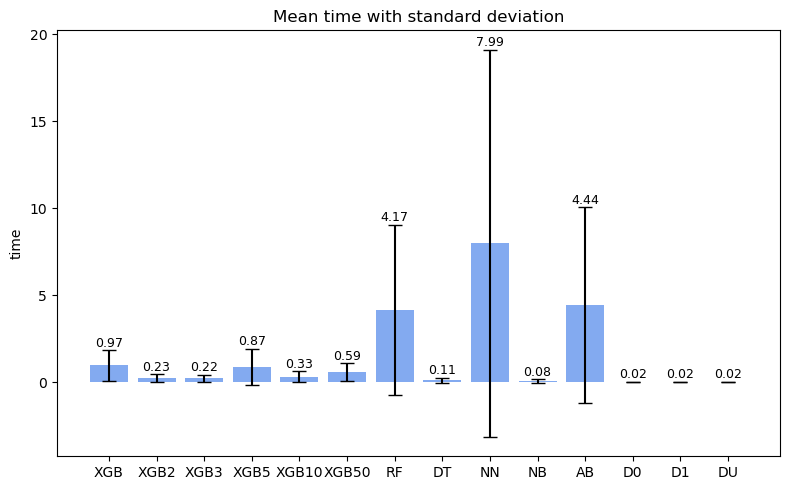

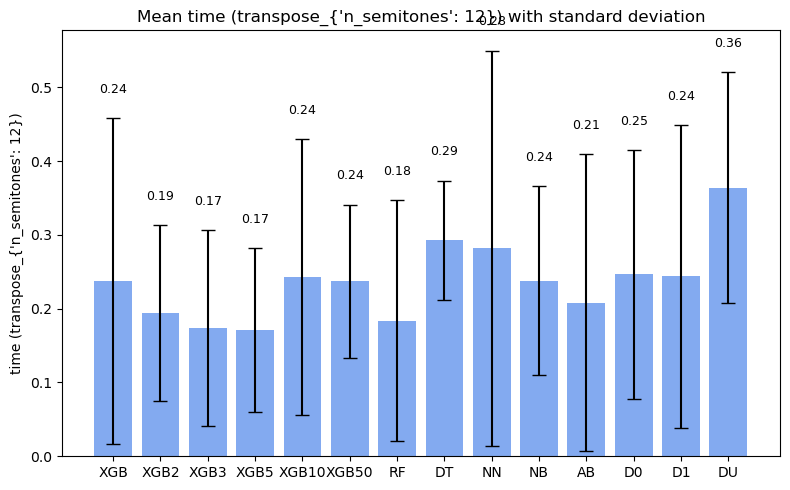

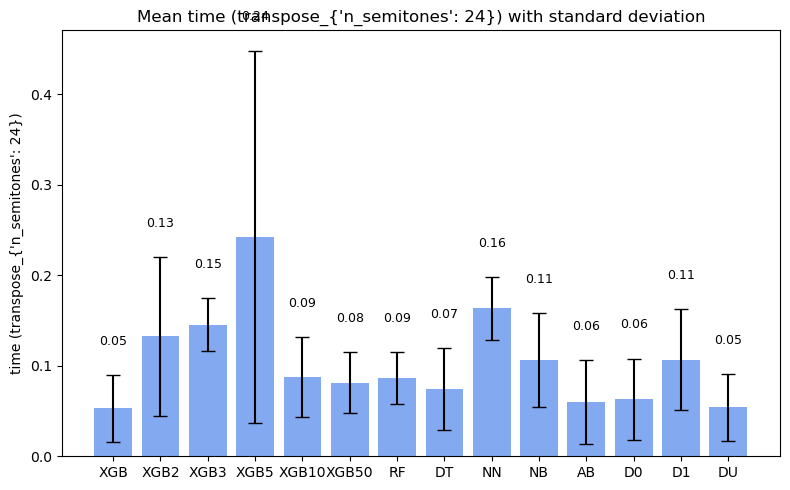

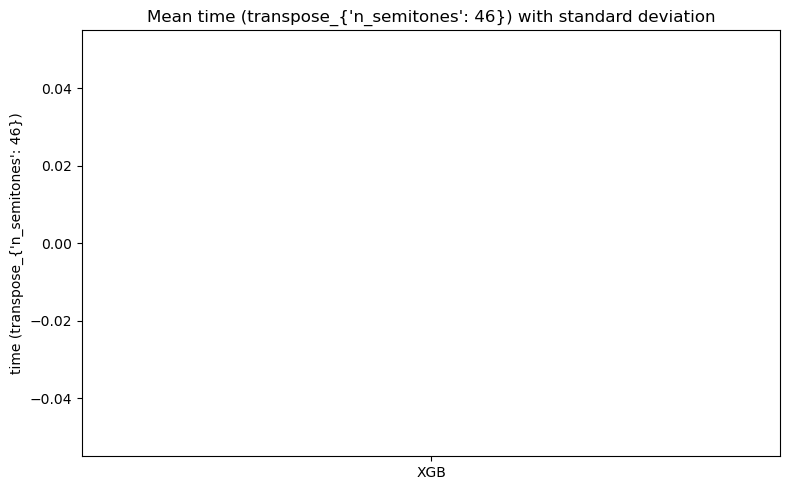

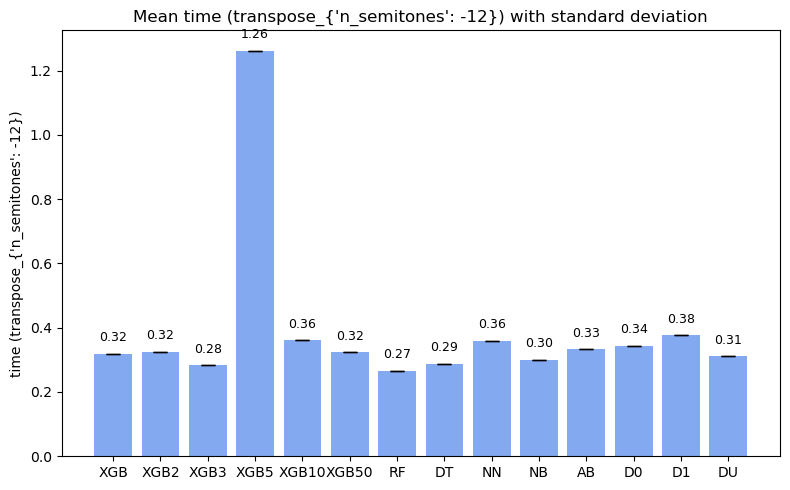

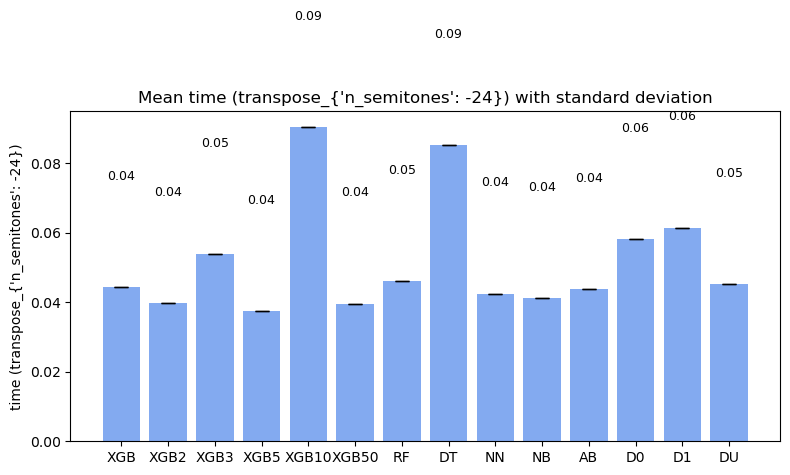

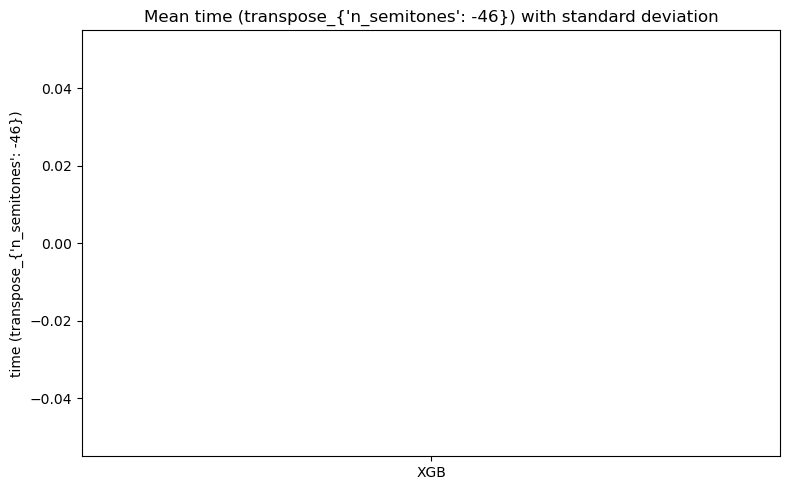

In [13]:
for mn in ml_metrics_names:
    if "time" in mn:
        # Plot
        plt.figure(figsize=(8, 5))
        barlist = plt.bar(model_names_short, metrics_mean[mn], yerr=metrics_std[mn], capsize=5, color='cornflowerblue', alpha=0.8)

        plt.ylabel(mn)
        plt.title(f'Mean {mn} with standard deviation')
        if not "time" in mn:
            plt.ylim(0, 1.1)

        # Optional: Add mean values above bars
        for i, (mean, std) in enumerate(zip(metrics_mean[mn], metrics_std[mn])):
            plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()

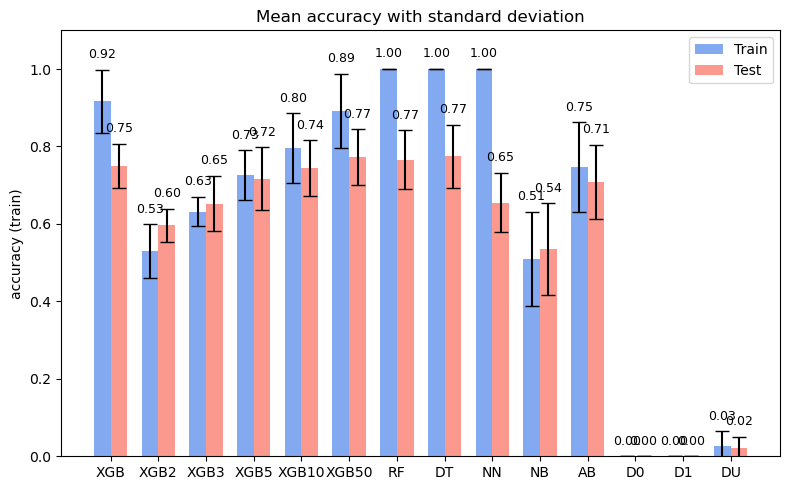

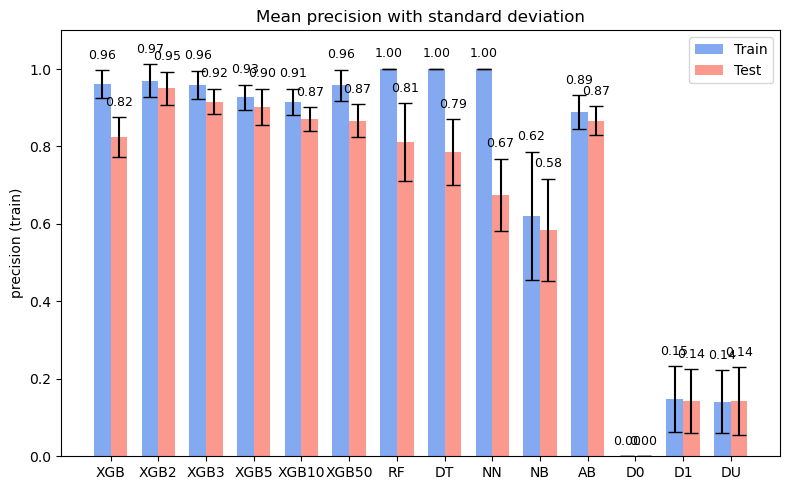

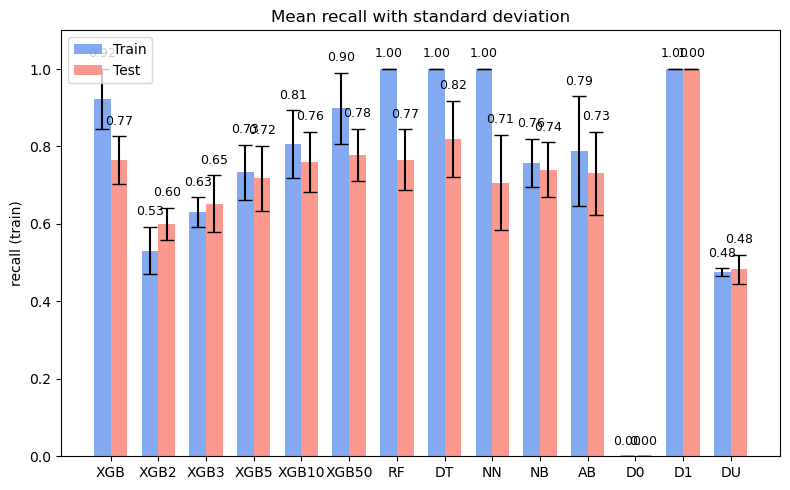

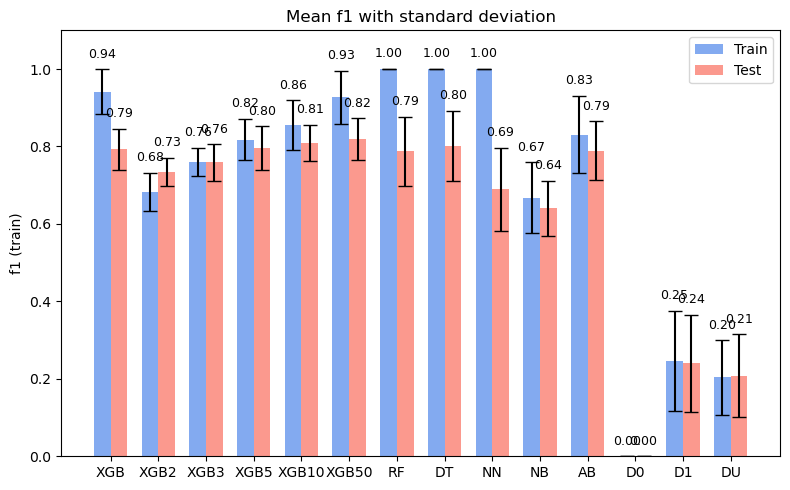

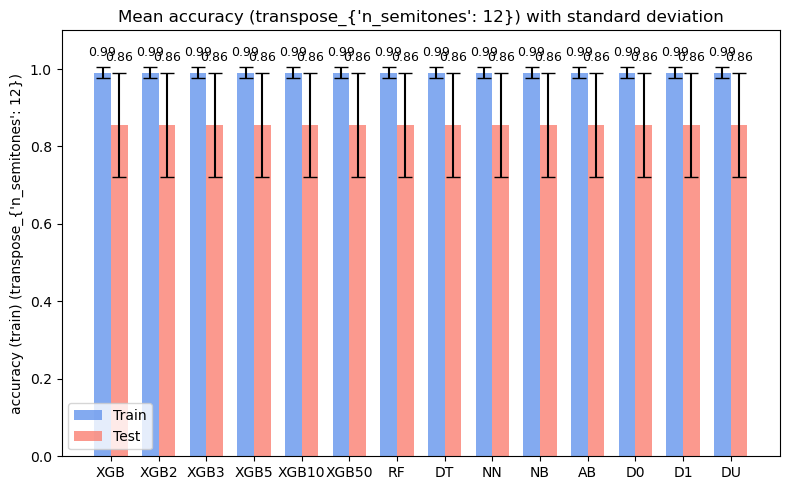

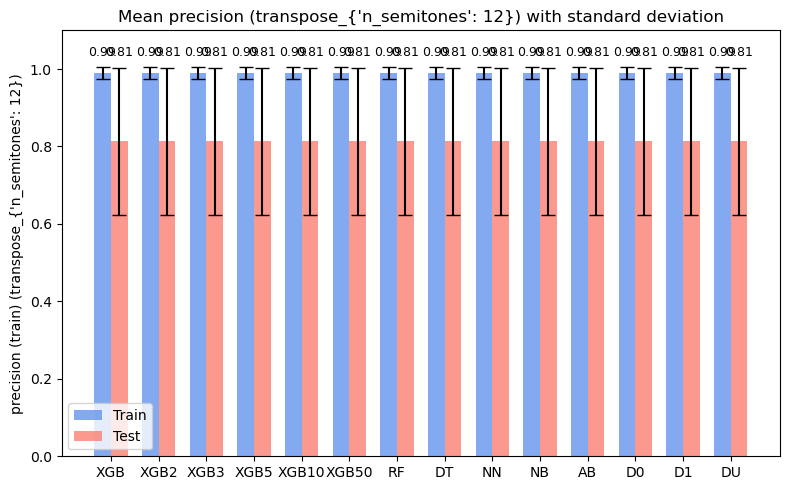

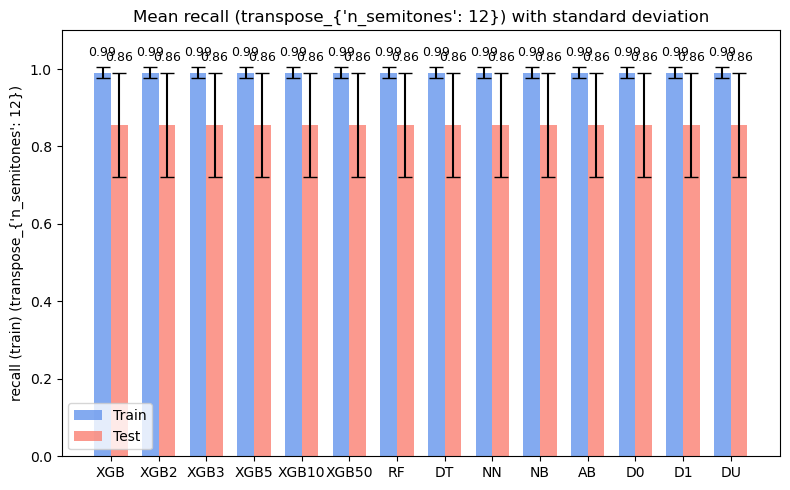

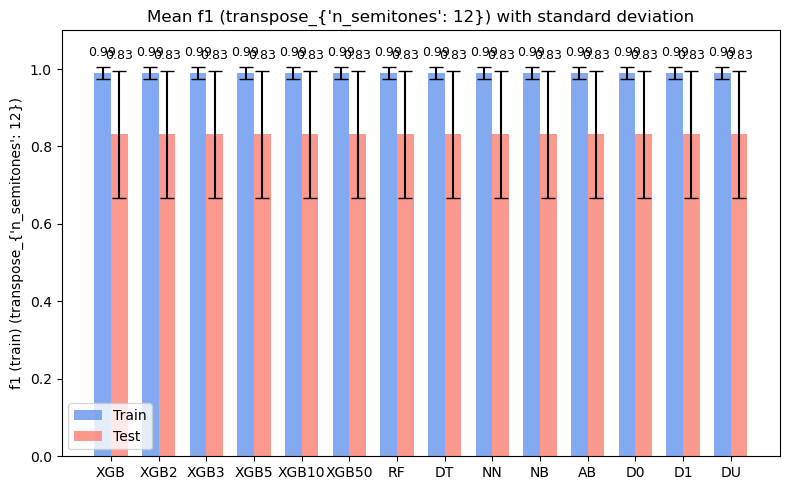

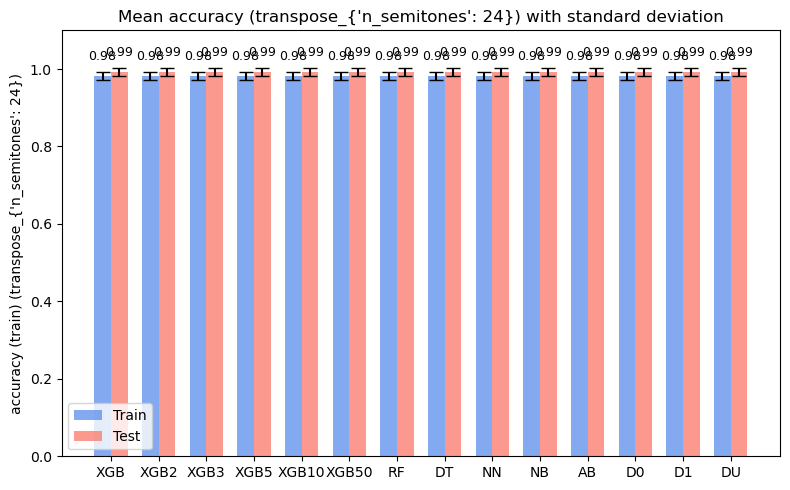

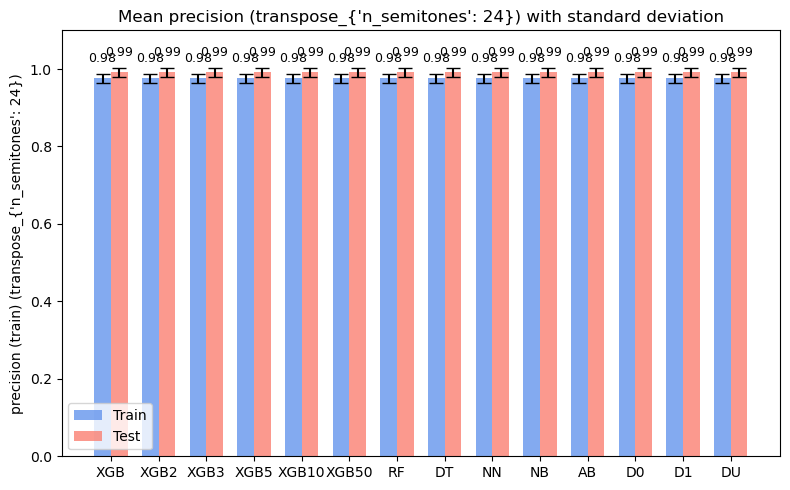

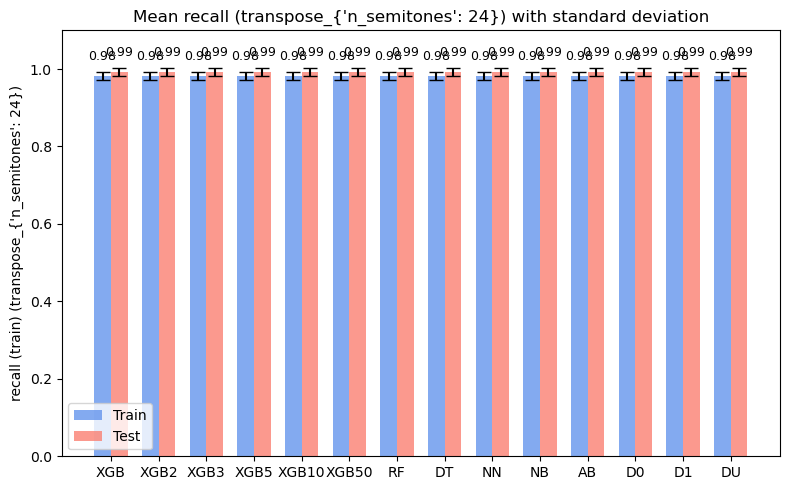

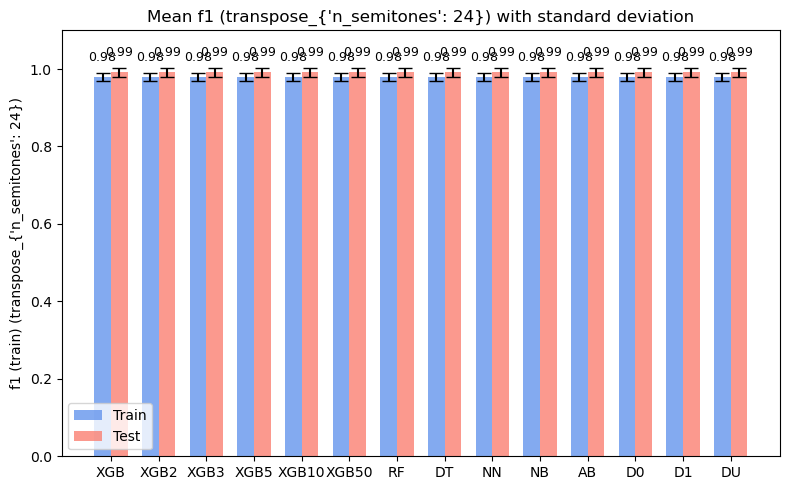

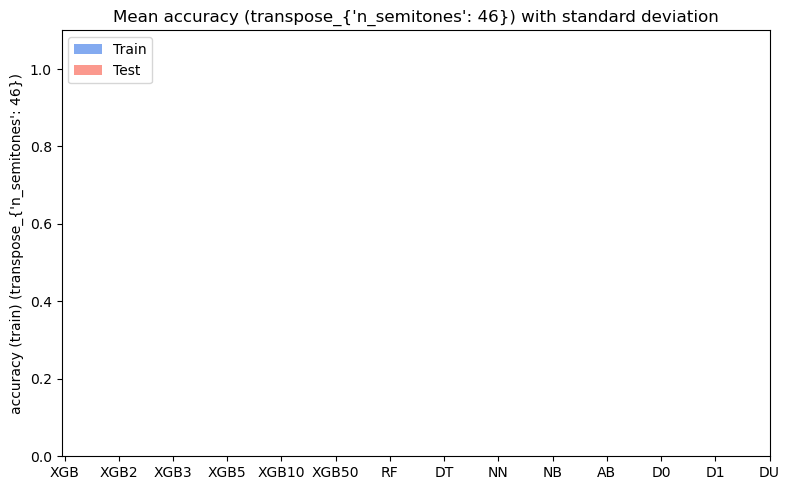

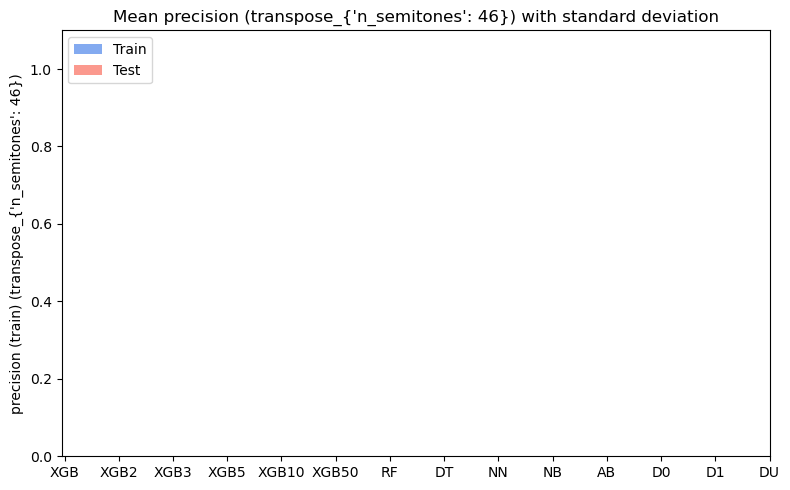

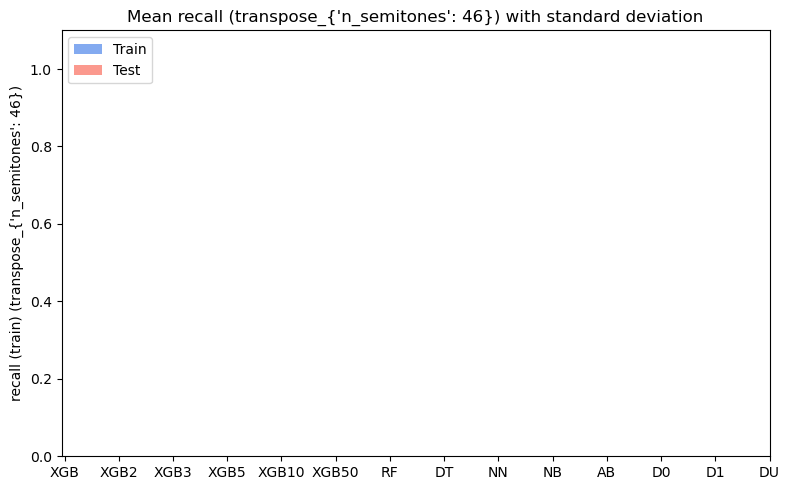

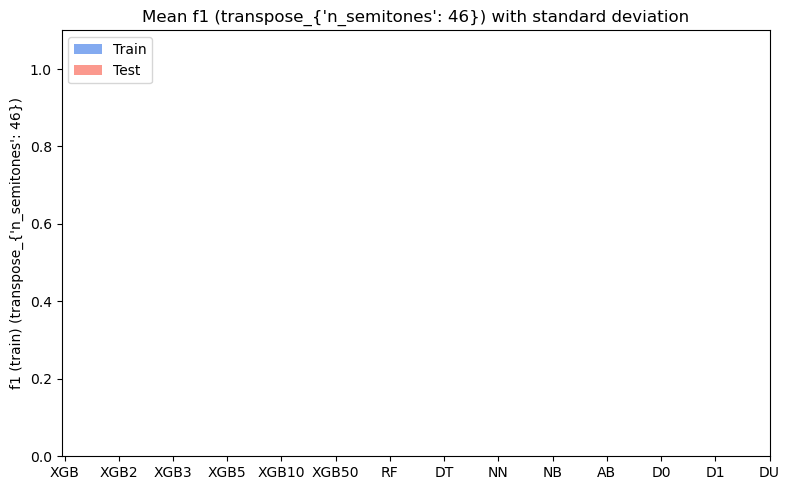

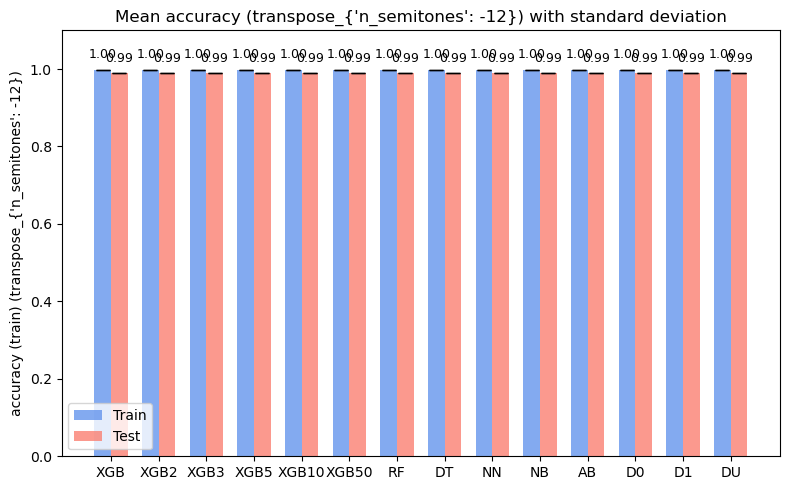

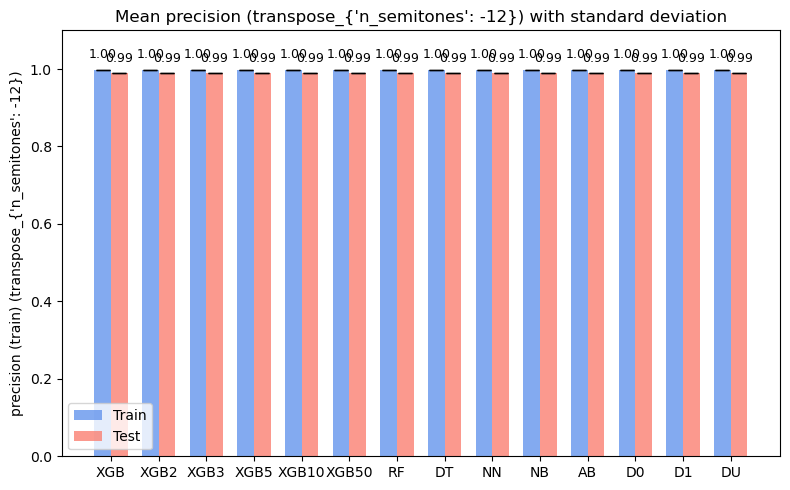

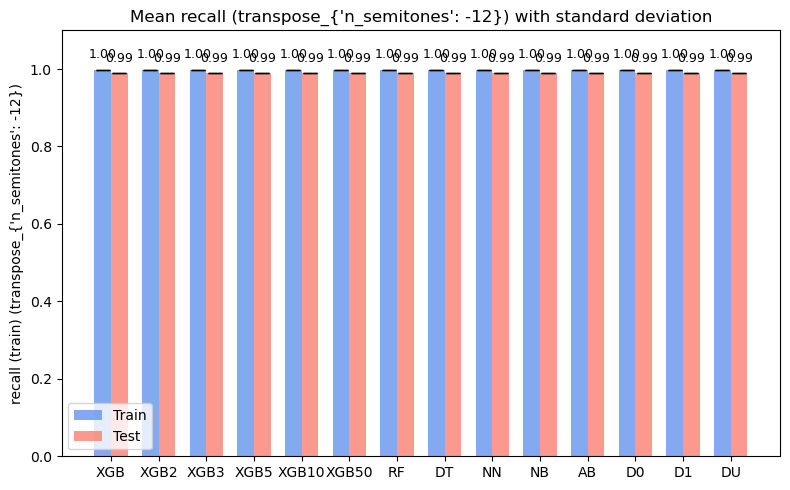

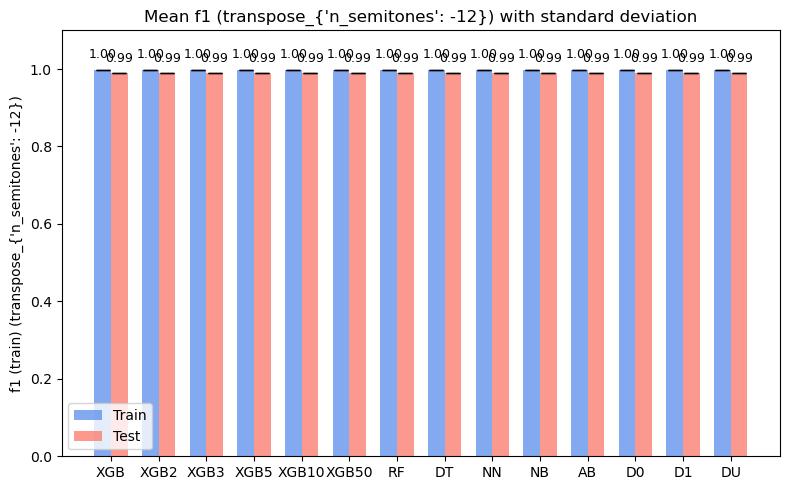

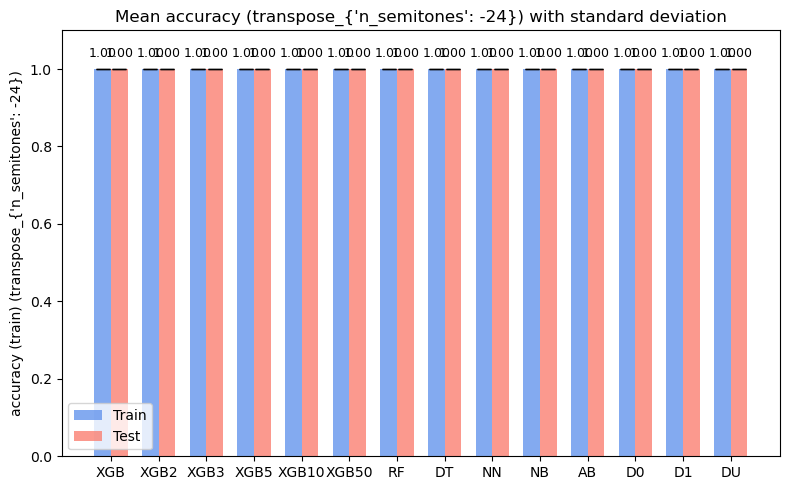

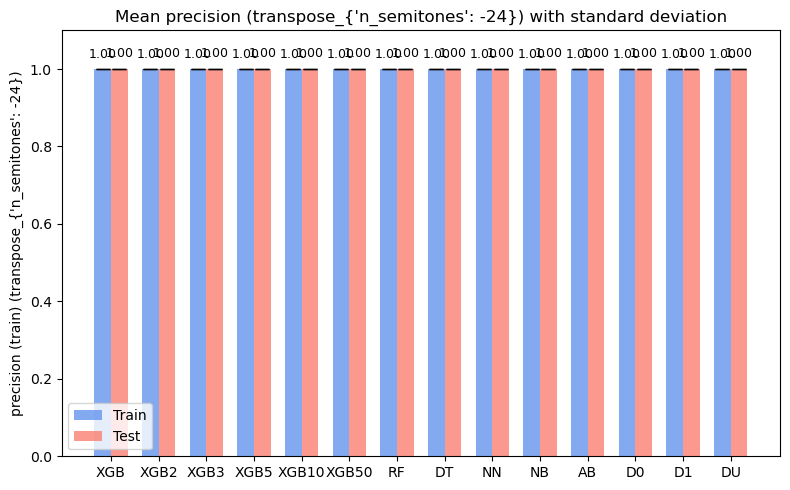

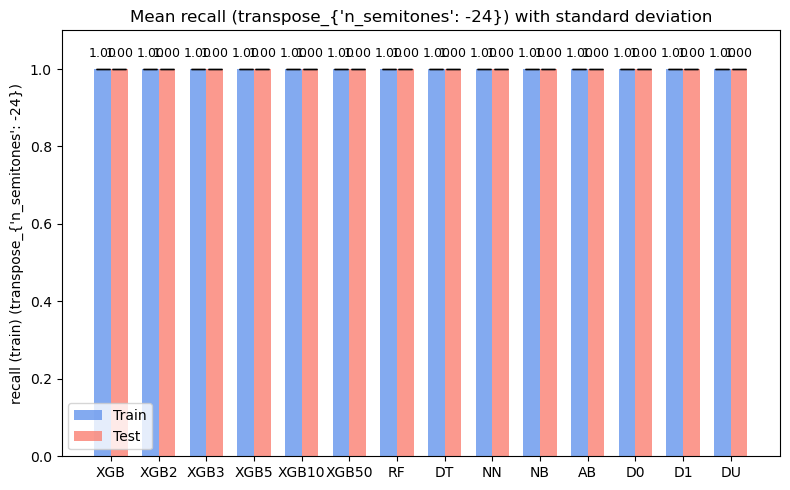

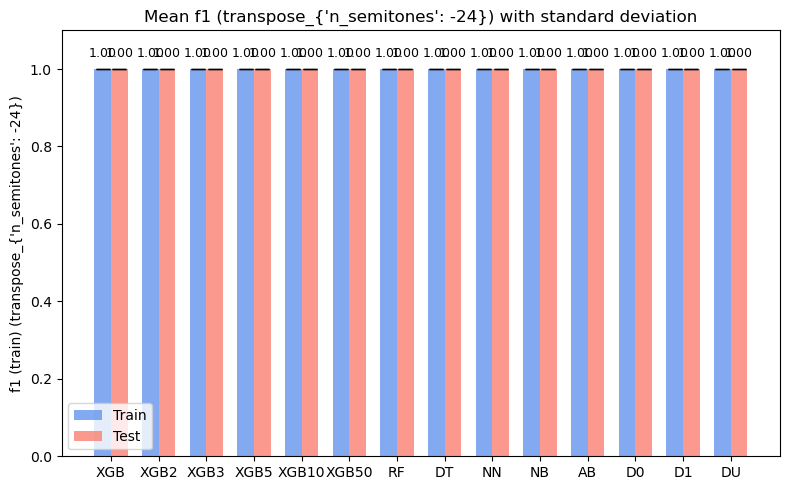

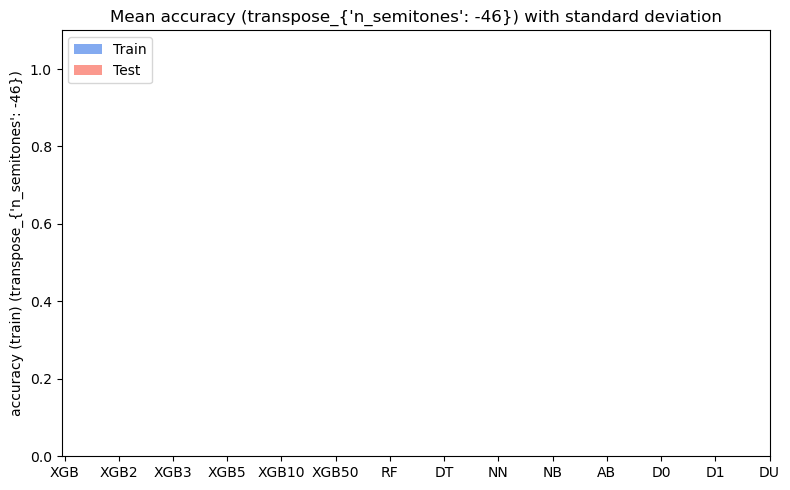

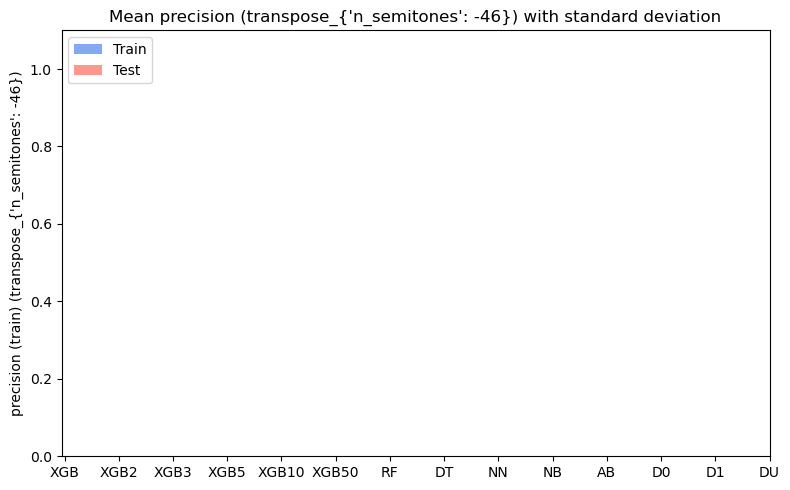

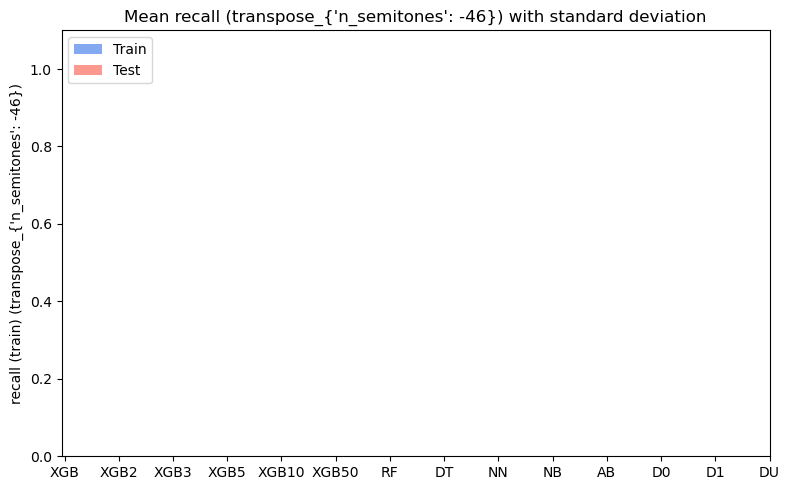

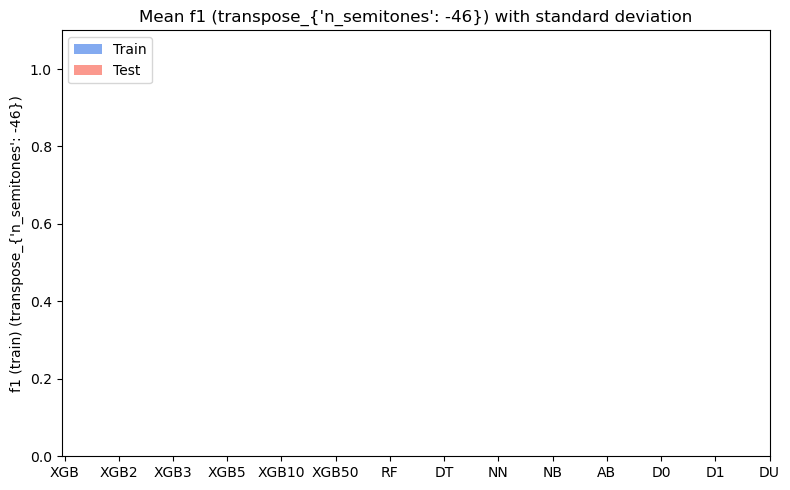

In [14]:
for mn in ml_metrics_names:
    if "train" in mn:
        mn_train = mn
        mn_test = mn.replace("train", "test")

        # Data for the two series
        train_means = metrics_mean[mn_train]
        test_means  = metrics_mean[mn_test]
        train_stds  = metrics_std[mn_train]
        test_stds   = metrics_std[mn_test]

        x = np.arange(len(model_names_short))   # positions
        width = 0.35

        plt.figure(figsize=(8, 5))

        # Two bar groups
        plt.bar(x - width/2, train_means, width,
                yerr=train_stds, capsize=5,
                label='Train', color='cornflowerblue', alpha=0.8)

        plt.bar(x + width/2, test_means, width,
                yerr=test_stds, capsize=5,
                label='Test', color='salmon', alpha=0.8)

        # Labels & layout
        plt.xticks(x, model_names_short)
        plt.ylabel(mn)
        plt.title(f'Mean {mn.replace(" (train)", "")} with standard deviation')

        if "time" not in mn:
            plt.ylim(0, 1.1)

        # Add mean value labels above bars
        for i, (mean, std) in enumerate(zip(train_means, train_stds)):
            plt.text(x[i] - width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=9)

        for i, (mean, std) in enumerate(zip(test_means, test_stds)):
            plt.text(x[i] + width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=9)

        plt.legend()
        plt.tight_layout()
        plt.show()

In [15]:
# Renitialize metrics collectors
s = (len(filenames),len(model_names))
ml_metrics = dict()
base_metrics_names = ["time",
                      "accuracy (train)",
                      "accuracy (test)",
                      "precision (train)",
                      "precision (test)",
                      "recall (train)",
                      "recall (test)",
                      "f1 (train)",
                      "f1 (test)",
                      ] #, "n_events", "n_classes"]
ml_metrics_names = base_metrics_names.copy()

for mn in ml_metrics_names:
    ml_metrics[mn] = np.zeros(s)

In [16]:
# Single-class, without transformations
error_collection = []
for i, filein in enumerate(filenames):    
    for u, (model_name, clf) in enumerate(zip(model_names, classifiers)):
        try: 
            metrics = amo_with_doublings_multiclass(filein,fileout=None,model=model_name, tol=0.2, transformations=None, multiclass=False)
            print(metrics)
            for mn in ml_metrics_names:
                # ml_metrics["accuracy"][i,u] = metrics["accuracy"]
                ml_metrics[mn][i,u] = metrics[mn]
        except Exception as e:
            print("Error")
            error_collection.append(f"Error with {filein} and model {model_name}: {e}")

print("\n????????? ERRORS ??????????")
for error in error_collection:
    print(error)

Learning orchestration style from: LOP_database_06_09_17/hand_picked_Spotify/2/symphony_9_2_orch.mid

========= PREPROCESSING =========
Mapping: [[3 'Corno inglese' 2 0]
 [5 'Clarinetti B' 4 0]
 [6 'Fagotti' 5 0]
 [15 'Violini I.' 11 0]
 [16 'Violini II.' 12 0]
 [17 'Viole' 13 0]
 [18 'Violoncelli' 14 0]
 [19 'Contrabassi' 15 0]]

Define covariates and target variable. Target variable encoding
Labels ['15_11' '16_12' '17_13' '18_14' '19_15' '3_2' '5_4' '6_5']
Number of events in LOP_database_06_09_17/hand_picked_Spotify/2/symphony_9_2_orch.mid : 212
Last onset at 58.002604166666664
Running in validation mode.
y_train, test size: 0.2 , labels: ['15_11' '16_12' '17_13' '18_14' '19_15' '3_2' '5_4' '6_5']
Number of unknown classes in test set: 0 of 0.2
y_train, test size: 0 , labels: ['15_11' '16_12' '17_13' '18_14' '19_15' '3_2' '5_4' '6_5']

========= TRAINING (with single-class option) =========

Instrument classification

--------- XGBoost ---------
Train Time (sec): 0.1992
Score on Te

In [17]:
metrics_mean = dict()
metrics_std = dict()
for mn in ml_metrics_names:
    metrics_mean[mn], metrics_std[mn] = return_m_std(ml_metrics[mn], mn)

time
[0.75612704 0.03519535 0.03894846 0.05012592 0.09944081 0.32195822
 0.61650181 0.01870807 0.42029444 0.01888688 0.33525904 0.00439246
 0.00466951 0.00480008]
[7.00764275e-01 2.38023682e-02 1.99148724e-02 3.67729360e-02
 6.95082615e-02 3.17432671e-01 6.85396715e-01 1.89719169e-02
 5.60130641e-01 1.89595579e-02 3.52795942e-01 6.58110063e-04
 7.56702819e-04 9.36821162e-04]
accuracy (train)
[0.95375932 0.86089733 0.86500371 0.87826315 0.90454084 0.94098041
 0.99802761 0.99802761 0.99802761 0.73871453 0.49887551 0.12796111
 0.13411506 0.13576604]
[0.05723036 0.07634648 0.079172   0.08409382 0.09198475 0.07128345
 0.00278938 0.00278938 0.00278938 0.03241324 0.23223747 0.07814737
 0.09970943 0.07196207]
accuracy (test)
[0.77548725 0.80006354 0.81698958 0.80609613 0.81745817 0.78391083
 0.7782151  0.78036385 0.70588509 0.71137793 0.46016677 0.15867956
 0.1233274  0.15544439]
[0.07656267 0.05774281 0.05742822 0.04722406 0.05219702 0.0716672
 0.06672521 0.06576716 0.14643222 0.01200039 0.19

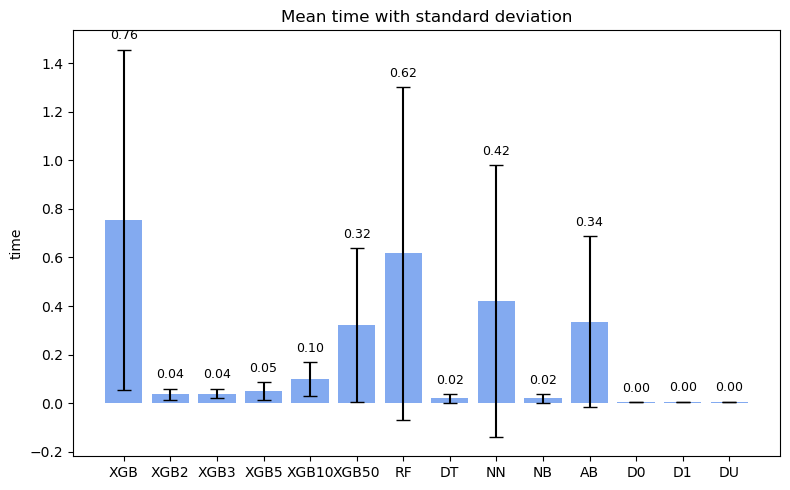

In [18]:
for mn in ml_metrics_names:
    if "time" in mn:
        # Plot
        plt.figure(figsize=(8, 5))
        barlist = plt.bar(model_names_short, metrics_mean[mn], yerr=metrics_std[mn], capsize=5, color='cornflowerblue', alpha=0.8)

        plt.ylabel(mn)
        plt.title(f'Mean {mn} with standard deviation')
        if not "time" in mn:
            plt.ylim(0, 1.1)

        # Optional: Add mean values above bars
        for i, (mean, std) in enumerate(zip(metrics_mean[mn], metrics_std[mn])):
            plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()

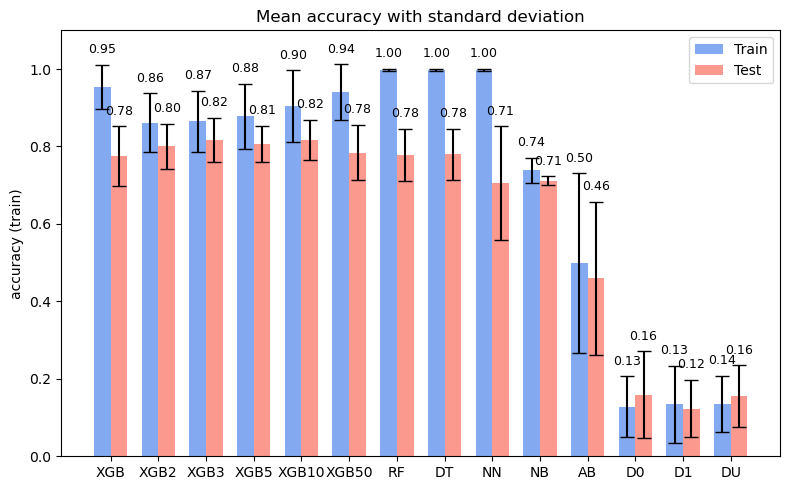

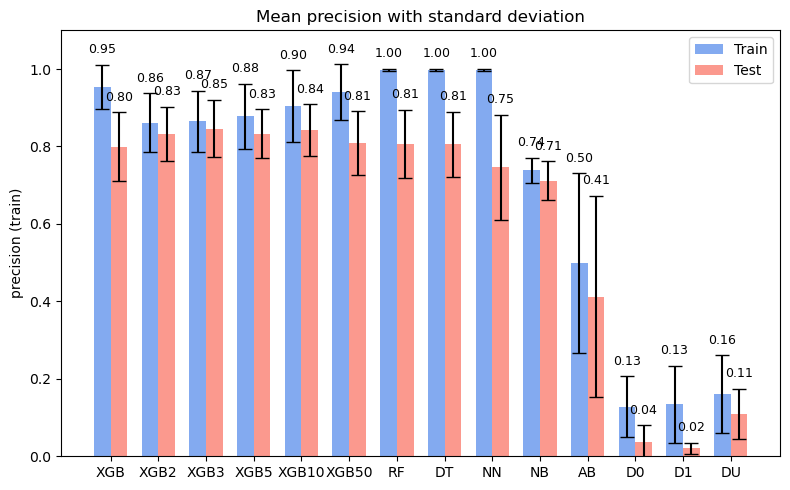

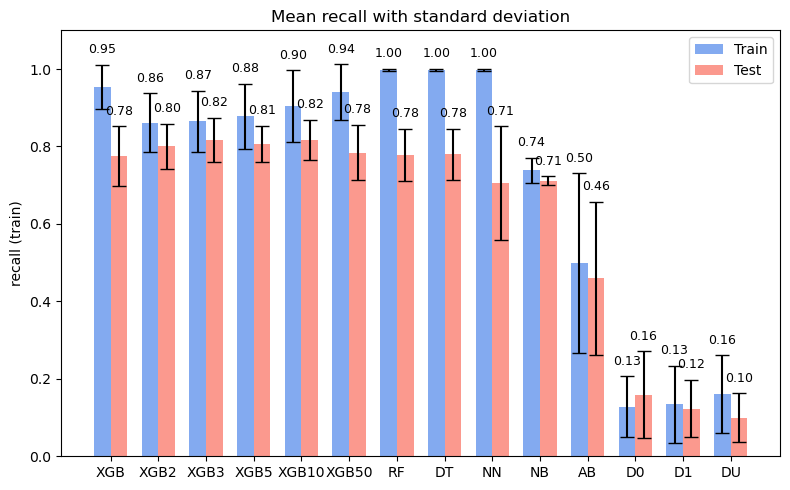

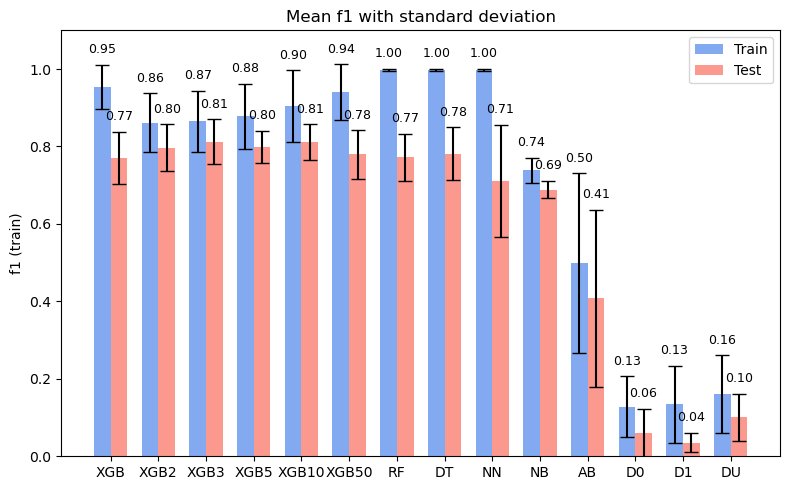

In [19]:
for mn in ml_metrics_names:
    if "train" in mn:
        mn_train = mn
        mn_test = mn.replace("train", "test")

        # Data for the two series
        train_means = metrics_mean[mn_train]
        test_means  = metrics_mean[mn_test]
        train_stds  = metrics_std[mn_train]
        test_stds   = metrics_std[mn_test]

        x = np.arange(len(model_names_short))   # positions
        width = 0.35

        plt.figure(figsize=(8, 5))

        # Two bar groups
        plt.bar(x - width/2, train_means, width,
                yerr=train_stds, capsize=5,
                label='Train', color='cornflowerblue', alpha=0.8)

        plt.bar(x + width/2, test_means, width,
                yerr=test_stds, capsize=5,
                label='Test', color='salmon', alpha=0.8)

        # Labels & layout
        plt.xticks(x, model_names_short)
        plt.ylabel(mn)
        plt.title(f'Mean {mn.replace(" (train)", "")} with standard deviation')

        if "time" not in mn:
            plt.ylim(0, 1.1)

        # Add mean value labels above bars
        for i, (mean, std) in enumerate(zip(train_means, train_stds)):
            plt.text(x[i] - width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=9)

        for i, (mean, std) in enumerate(zip(test_means, test_stds)):
            plt.text(x[i] + width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=9)

        plt.legend()
        plt.tight_layout()
        plt.show()